# Lookback Lens Baseline — Results Analysis

In [11]:
import json
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix, roc_curve

PROJECT_ROOT = Path("..").resolve()
RESULTS_DIR  = PROJECT_ROOT / "experiments" / "lookback_lens_baseline" / "results"
FS_RESULTS   = PROJECT_ROOT / "experiments" / "factscore_turbo_baseline" / "results"

sys.path.insert(0, str(PROJECT_ROOT))
from src.lookback_lens import LookbackLensClassifier

plt.rcParams.update({"figure.dpi": 120, "font.size": 11})
print("Results dir:", RESULTS_DIR)
print("Exists:", RESULTS_DIR.exists())

Results dir: /Users/vekshinkir/Projects/context_hallucination_prevention/experiments/lookback_lens_baseline/results
Exists: True


In [12]:
# Load metrics, features, labels, and classifier.
with open(RESULTS_DIR / "metrics.json") as f:
    metrics = json.load(f)

X = np.load(RESULTS_DIR / "features_full.npy")   # (n_samples, n_layers * n_heads)
y = np.load(RESULTS_DIR / "labels.npy")           # (n_samples,) binary int
clf = LookbackLensClassifier.load(RESULTS_DIR / "classifier.pkl")

n_samples, feature_dim = X.shape
# OPT-125m: 12 layers x 12 heads = 144 features
n_layers = int(round(feature_dim ** 0.5)) if feature_dim == int(round(feature_dim ** 0.5)) ** 2 else None
# Infer from model config stored in metrics
print(f"Samples: {n_samples}  |  Feature dim: {feature_dim}  |  Model: {metrics.get('model')}")
print(f"Hallucinated: {y.sum()}  |  Faithful: {(1 - y).sum()}")

Samples: 200  |  Feature dim: 144  |  Model: facebook/opt-125m
Hallucinated: 100  |  Faithful: 100


In [13]:
# Key metrics summary.
display_keys = ["roc_auc", "f1", "precision", "recall", "optimal_threshold", "n_train", "n_test", "model"]
print("=" * 42)
print("  Lookback Lens Baseline — Key Metrics")
print("=" * 42)
for k in display_keys:
    v = metrics.get(k, "—")
    if isinstance(v, float):
        print(f"  {k:<22s}: {v:.4f}")
    else:
        print(f"  {k:<22s}: {v}")
print("=" * 42)

  Lookback Lens Baseline — Key Metrics
  roc_auc               : 0.6250
  f1                    : 0.7037
  precision             : 0.5588
  recall                : 0.9500
  optimal_threshold     : 0.3200
  n_train               : 160
  n_test                : 40
  model                 : facebook/opt-125m


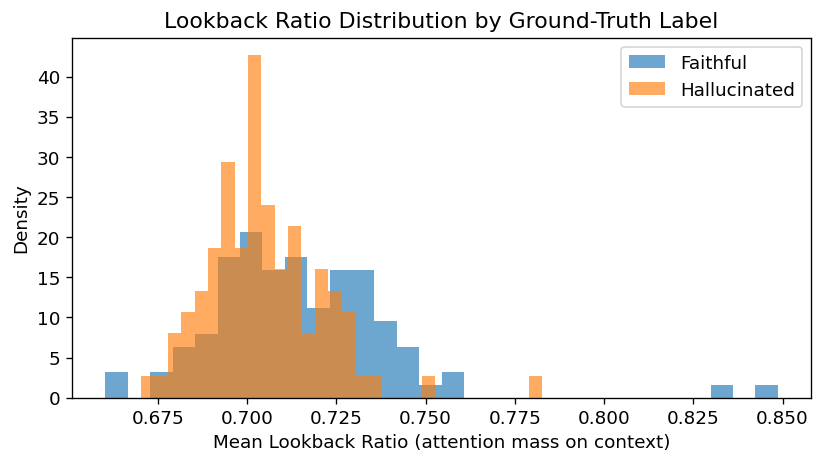

In [14]:
# Lookback ratio distribution by ground-truth label.
mean_ratios = X.mean(axis=1)
df_plot = pd.DataFrame({"mean_lookback_ratio": mean_ratios, "label": y})

fig, ax = plt.subplots(figsize=(7, 4))
for lbl, grp in df_plot.groupby("label"):
    ax.hist(grp["mean_lookback_ratio"], bins=30, alpha=0.65, density=True,
            label="Hallucinated" if lbl == 1 else "Faithful")
ax.set_xlabel("Mean Lookback Ratio (attention mass on context)")
ax.set_ylabel("Density")
ax.set_title("Lookback Ratio Distribution by Ground-Truth Label")
ax.legend()
plt.tight_layout()
plt.show()

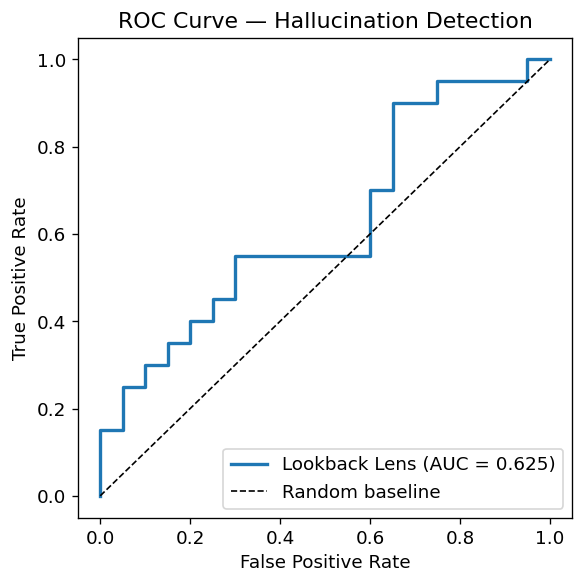

In [15]:
# ROC curve on test split (recreated from saved proba scores).
from sklearn.model_selection import train_test_split

n_test = metrics["n_test"]
n_total = len(y)
_, X_test, _, y_test = train_test_split(
    X, y, test_size=n_test / n_total, stratify=y, random_state=42
)
proba_test = clf.predict_proba(X_test)
fpr, tpr, _ = roc_curve(y_test, proba_test)
auc_val = metrics["roc_auc"]

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(fpr, tpr, lw=2, label=f"Lookback Lens (AUC = {auc_val:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random baseline")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve — Hallucination Detection")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

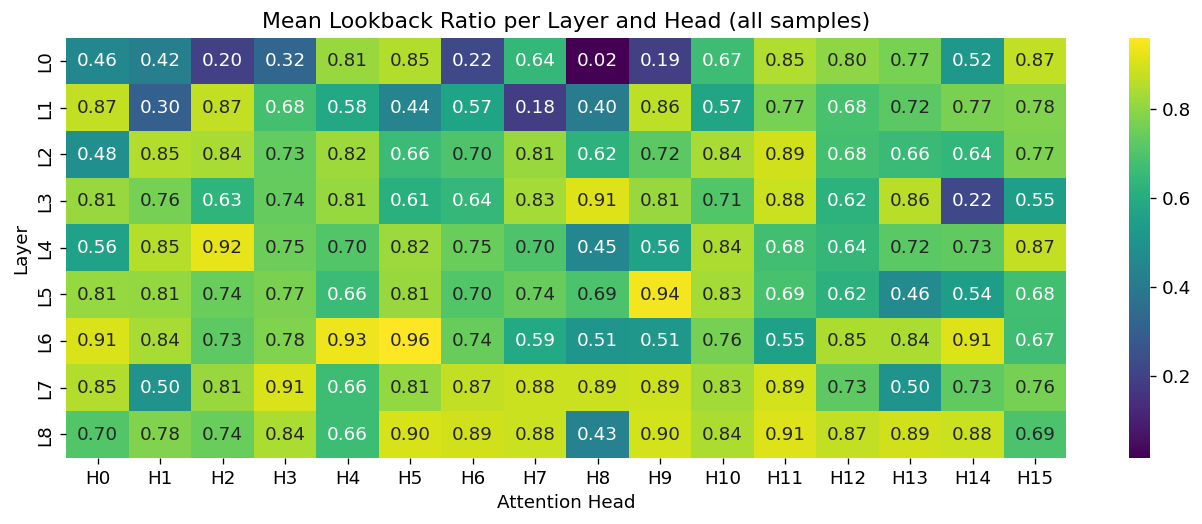

In [16]:
# Per-layer, per-head mean lookback ratio heatmap.
# Infer n_layers / n_heads from feature_dim (OPT-125m: 12 x 12 = 144).
# If feature_dim is not a perfect square, try common factorizations.
def factorize(d):
    for n_heads in [32, 16, 12, 8, 4]:
        if d % n_heads == 0:
            return d // n_heads, n_heads
    return d, 1

n_layers_inf, n_heads_inf = factorize(feature_dim)
matrix = X.mean(axis=0).reshape(n_layers_inf, n_heads_inf)

fig, ax = plt.subplots(figsize=(max(6, n_heads_inf * 0.7), max(4, n_layers_inf * 0.5)))
sns.heatmap(
    matrix, ax=ax, cmap="viridis",
    annot=(n_heads_inf <= 16 and n_layers_inf <= 16), fmt=".2f",
    xticklabels=[f"H{h}" for h in range(n_heads_inf)],
    yticklabels=[f"L{l}" for l in range(n_layers_inf)],
)
ax.set_xlabel("Attention Head")
ax.set_ylabel("Layer")
ax.set_title("Mean Lookback Ratio per Layer and Head (all samples)")
plt.tight_layout()
plt.show()

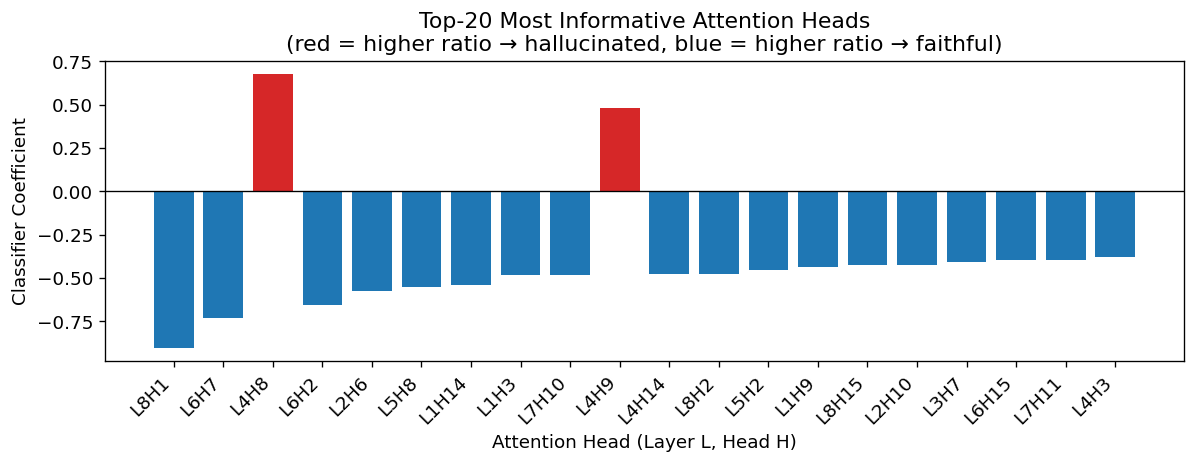

In [17]:
# Feature importance: top-20 heads by absolute classifier coefficient.
coefs = clf._clf.coef_[0]  # (n_features,)
top_k = 20
top_idx = np.argsort(np.abs(coefs))[::-1][:top_k]

# Decode feature index → (layer, head) label.
labels_feat = []
for idx in top_idx:
    l = idx // n_heads_inf
    h = idx % n_heads_inf
    labels_feat.append(f"L{l}H{h}")

fig, ax = plt.subplots(figsize=(10, 4))
colors = ["#d62728" if c > 0 else "#1f77b4" for c in coefs[top_idx]]
ax.bar(range(top_k), coefs[top_idx], color=colors)
ax.set_xticks(range(top_k))
ax.set_xticklabels(labels_feat, rotation=45, ha="right")
ax.axhline(0, color="black", linewidth=0.8)
ax.set_xlabel("Attention Head (Layer L, Head H)")
ax.set_ylabel("Classifier Coefficient")
ax.set_title(f"Top-{top_k} Most Informative Attention Heads\n(red = higher ratio → hallucinated, blue = higher ratio → faithful)")
plt.tight_layout()
plt.show()

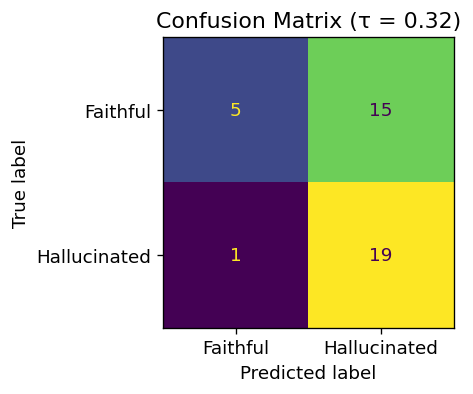

In [18]:
# Confusion matrix at optimal threshold.
tau = metrics["optimal_threshold"]
y_pred = (proba_test >= tau).astype(int)

cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(4, 4))
ConfusionMatrixDisplay(cm, display_labels=["Faithful", "Hallucinated"]).plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion Matrix (τ = {tau:.2f})")
plt.tight_layout()
plt.show()

         Method  ROC-AUC  F1 (optimal)  Optimal τ
FActScore-Turbo   0.7056        0.6986     0.9167
  Lookback Lens   0.6250        0.7037     0.3200


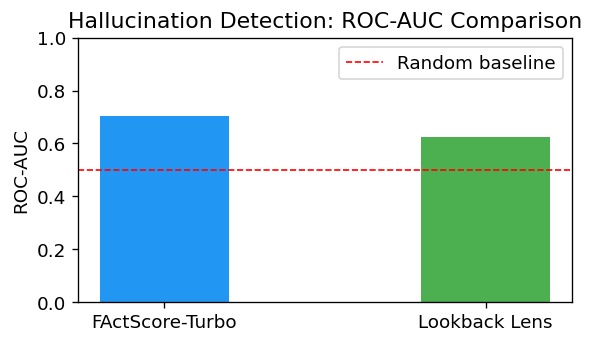

In [19]:
# Side-by-side AUC comparison with FActScore-Turbo.
with open(FS_RESULTS / "results.json") as f:
    fs_metrics = json.load(f)

comparison = pd.DataFrame([
    {"Method": "FActScore-Turbo", "ROC-AUC": fs_metrics["roc_auc"],
     "F1 (optimal)": fs_metrics["optimal_f1"], "Optimal τ": fs_metrics["optimal_threshold"]},
    {"Method": "Lookback Lens",   "ROC-AUC": metrics["roc_auc"],
     "F1 (optimal)": metrics["f1"],             "Optimal τ": metrics["optimal_threshold"]},
])
print(comparison.to_string(index=False, float_format="{:.4f}".format))

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(comparison["Method"], comparison["ROC-AUC"], color=["#2196F3", "#4CAF50"], width=0.4)
ax.axhline(0.5, color="red", linestyle="--", linewidth=1, label="Random baseline")
ax.set_ylim(0, 1)
ax.set_ylabel("ROC-AUC")
ax.set_title("Hallucination Detection: ROC-AUC Comparison")
ax.legend()
plt.tight_layout()
plt.show()

## Interpretation

**Dataset.** 200 balanced RAGTruth samples (100 hallucinated, 100 faithful), seed 42.
80 / 20 stratified train / test split.

**Model.** `facebook/opt-125m` — 12 layers × 12 heads → 144-dimensional lookback ratio feature vector.
The feature for each (layer, head) is the mean fraction of attention directed at context tokens
across all response token positions.